# Correlation Analysis: Features vs IRAF SAT

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

IRAF_PATH = '../data/original/Final_IRAF_SAT_Bedömare sep och gemensamt_AL.xlsx'
FEATURES_DIR = '../data/processed/features/'

# Participant → videos mapping
PARTICIPANT_VIDEOS = {
    'Fp1': [28, 30],
    'Fp2': [45, 47],
    'Fp3': [59, 61],
    'Fp4': [74, 76],
    'Fp5': [91, 93],
}


Spearman correlations between pose features and IRAF SAT consensus deviation scores (`Gem_Avvikelse`) per phase. 

Features averaged over 2 videos per participant (n=5).


In [39]:
def parse_iraf_sheet(xl, sheet_name):
    raw = xl.parse(sheet_name, header=None)
    col0 = raw.iloc[:, 0].astype(str)
    block_rows = raw.index[col0.str.match(r'Fp\d_')].tolist()
    block_rows.append(len(raw))
    records = []
    for i, start in enumerate(block_rows[:-1]):
        fp = col0.iloc[start].split('_')[0]
        items = raw.iloc[start+1:block_rows[i+1]].reset_index(drop=True)[[0, 1, 12]]
        items.columns = ['Criterion', 'Weight', 'Gem']
        def find(label):
            m = items[items['Criterion'].astype(str).str.strip() == label].index
            return m[0] if len(m) else None
        rs, ru = find('Rörelsestart'), find('Rörelseutförande')
        for phase, sl in [('utgångsposition', items[:rs]), ('rörelsestart', items[rs+1:ru]), ('rörelseutförande', items[ru+1:])]:
            for _, r in sl.dropna(subset=['Gem']).iterrows():
                records.append({'participant': fp, 'phase': phase, 'weight': r['Weight'], 'gem': r['Gem']})
    return pd.DataFrame(records)

iraf = parse_iraf_sheet(pd.ExcelFile(IRAF_PATH), 'Sittande till stående')
iraf = iraf.assign(w=iraf['gem'] * iraf['weight'])

iraf_agg = iraf.groupby(['participant', 'phase'])['w'].sum().unstack().reset_index()
iraf_agg.columns.name = None
iraf_total = iraf.groupby('participant')['w'].sum().reset_index().rename(columns={'w': 'iraf_total'})


In [40]:
video_to_fp = {v: fp for fp, vids in PARTICIPANT_VIDEOS.items() for v in vids}

def load_features(name):
    df = pd.read_csv(FEATURES_DIR + f'{name}.csv')
    return df.assign(participant=df['video'].map(video_to_fp)).drop(columns='video').groupby('participant').mean().reset_index()

feat_up = load_features('utgångsposition')
feat_rs = load_features('rörelsestart')
feat_ru = load_features('rörelseutförande')

merged_up = feat_up.merge(iraf_agg[['participant', 'utgångsposition']].rename(columns={'utgångsposition': 'iraf_score'}), on='participant')
merged_rs = feat_rs.merge(iraf_agg[['participant', 'rörelsestart']].rename(columns={'rörelsestart': 'iraf_score'}), on='participant')
merged_ru = feat_ru.merge(iraf_agg[['participant', 'rörelseutförande']].rename(columns={'rörelseutförande': 'iraf_score'}), on='participant')


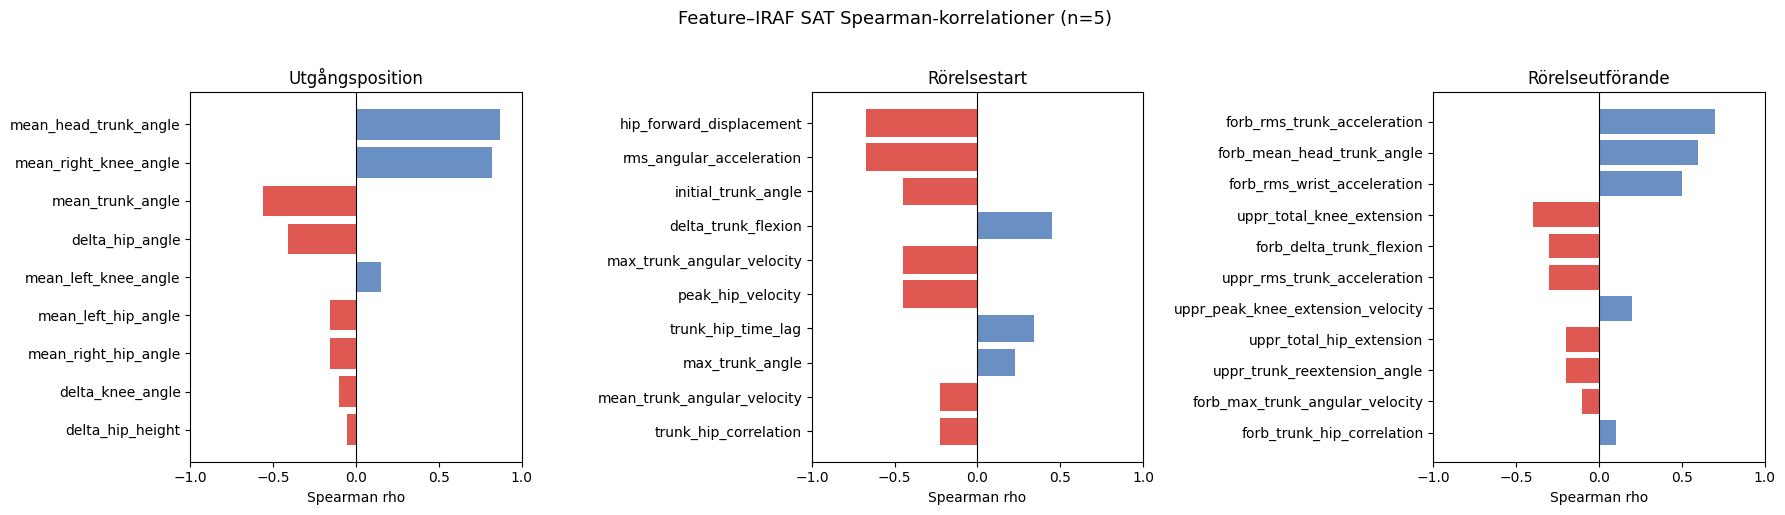

In [41]:
def spearman(df):
    return pd.DataFrame([
        {'feature': c, 'rho': stats.spearmanr(df[c], df['iraf_score'])[0],
                       'p':   stats.spearmanr(df[c], df['iraf_score'])[1]}
        for c in df.columns if c not in ['participant', 'iraf_score']
        if df[[c, 'iraf_score']].dropna().__len__() >= 3
    ]).sort_values('rho', key=abs, ascending=False)

corr_up = spearman(merged_up)
corr_rs = spearman(merged_rs)
corr_ru = spearman(merged_ru)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, corr, title in zip(axes, [corr_up, corr_rs, corr_ru], ['Utgångsposition', 'Rörelsestart', 'Rörelseutförande']):
    c = corr.set_index('feature')
    ax.barh(c.index, c['rho'], color=['#d73027' if r < 0 else '#4575b4' for r in c['rho']], alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Spearman rho')
    ax.set_title(title)
    ax.invert_yaxis()
    for i, (_, row) in enumerate(c.iterrows()):
        if row['p'] < 0.05:
            ax.text(row['rho'] + (0.03 if row['rho'] >= 0 else -0.03), i, '*', ha='center', va='center', fontsize=12)
plt.suptitle('Feature–IRAF SAT Spearman-korrelationer (n=5)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/features/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


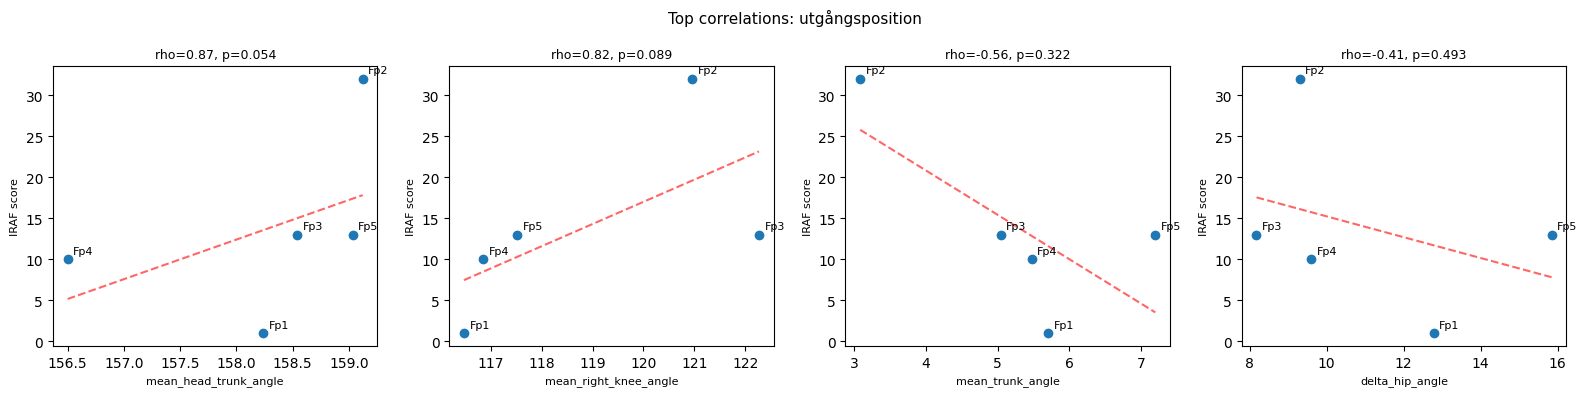

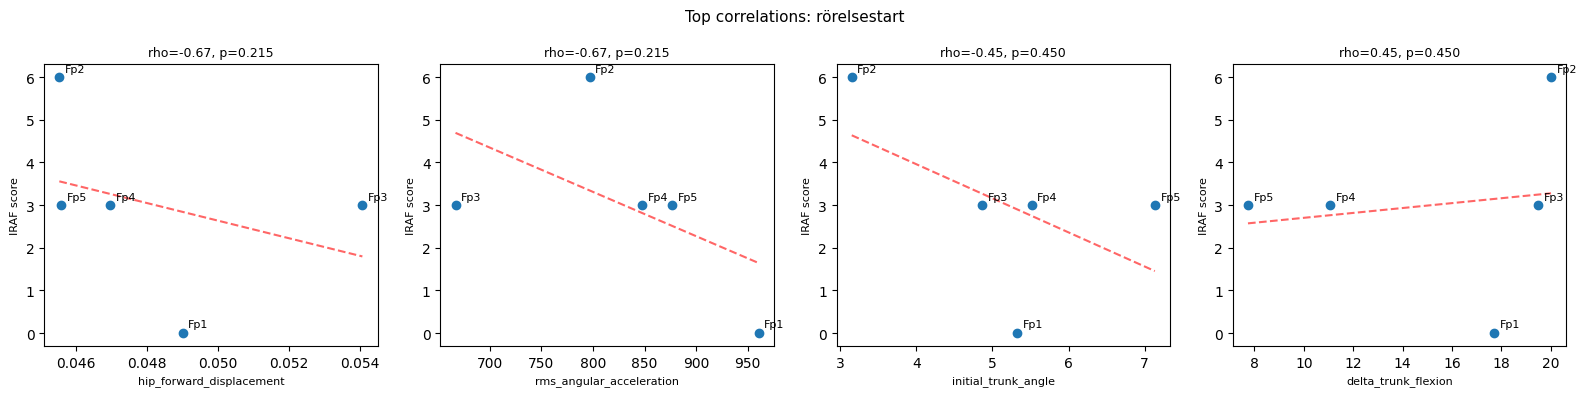

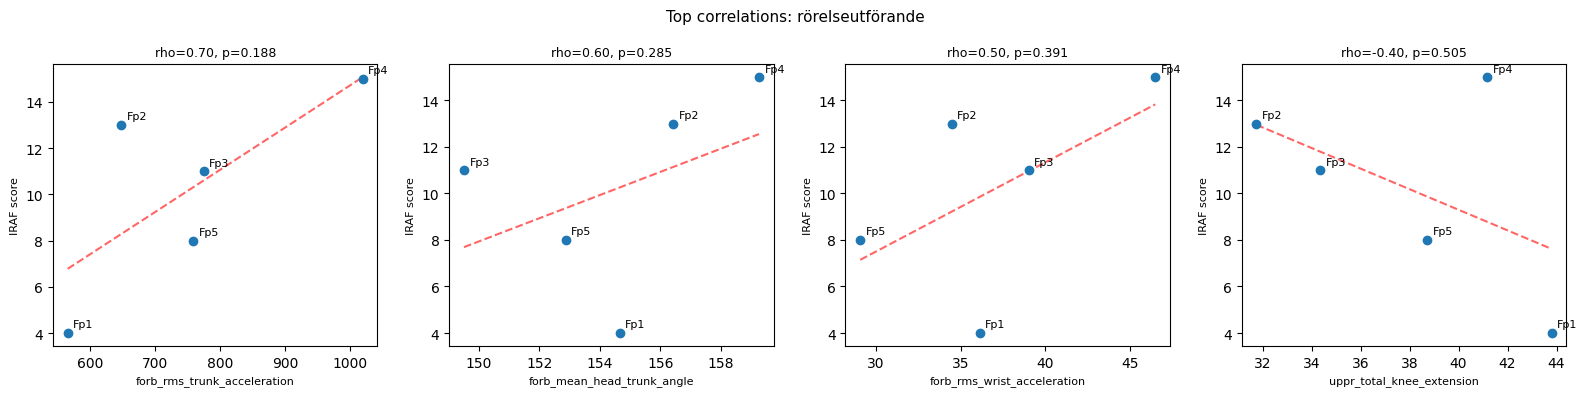

In [42]:
def plot_top_scatters(merged_df, corr_df, phase_name, n_top=4):
    top = corr_df.head(n_top)
    fig, axes = plt.subplots(1, len(top), figsize=(4*len(top), 4))
    if len(top) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, top.iterrows()):
        fc = row['feature']
        vals = merged_df[['participant', fc, 'iraf_score']].dropna()
        ax.scatter(vals[fc], vals['iraf_score'], zorder=3)
        for _, r in vals.iterrows():
            ax.annotate(r['participant'], (r[fc], r['iraf_score']),
                        textcoords='offset points', xytext=(4, 4), fontsize=8)
        m, b = np.polyfit(vals[fc], vals['iraf_score'], 1)
        xr = np.linspace(vals[fc].min(), vals[fc].max(), 50)
        ax.plot(xr, m*xr+b, 'r--', alpha=0.6)
        ax.set_xlabel(fc, fontsize=8)
        ax.set_ylabel('IRAF score', fontsize=8)
        ax.set_title(f'rho={row["rho"]:.2f}, p={row["p"]:.3f}', fontsize=9)
    fig.suptitle(f'Top correlations: {phase_name}', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'../data/processed/features/scatter_{phase_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_top_scatters(merged_up, corr_up, 'utgångsposition')
plot_top_scatters(merged_rs, corr_rs, 'rörelsestart')
plot_top_scatters(merged_ru, corr_ru, 'rörelseutförande')


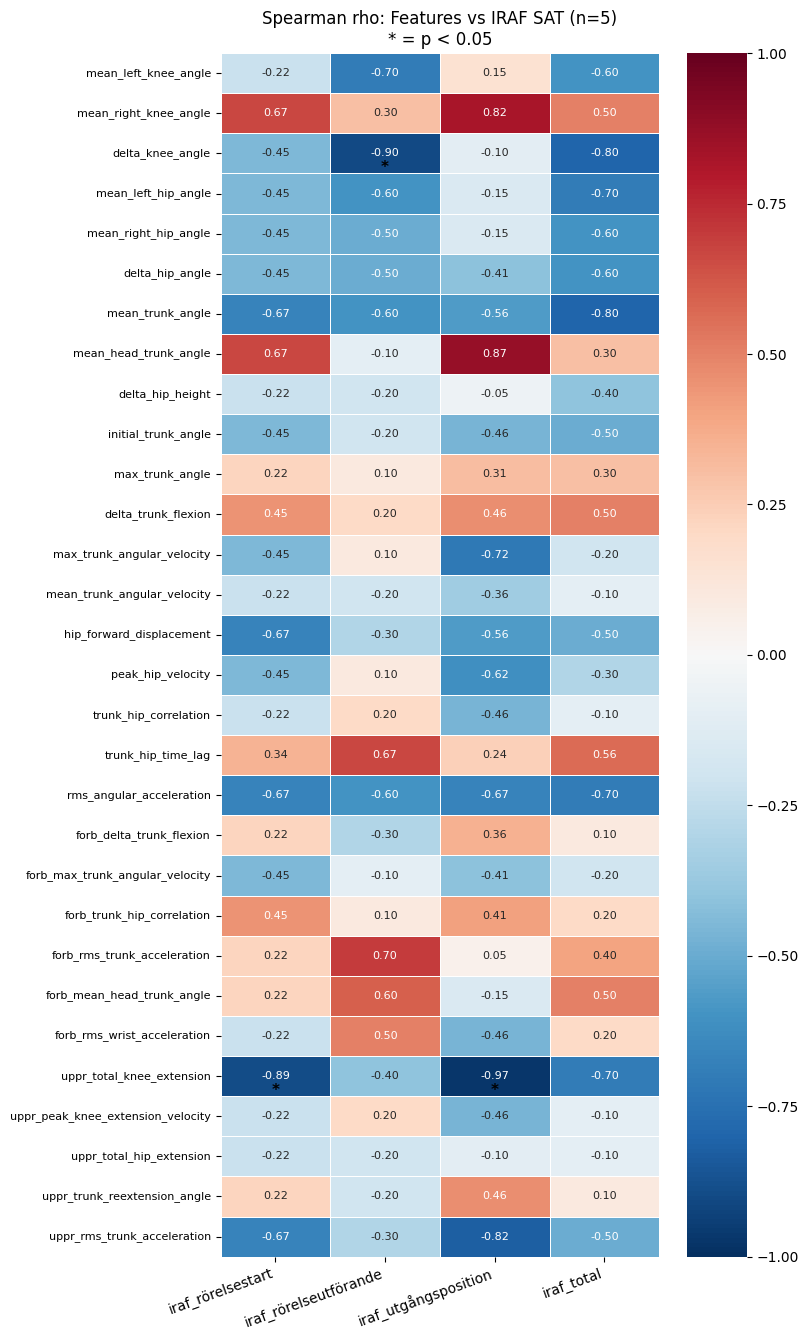

In [43]:
all_feats = feat_up.merge(feat_rs, on='participant', how='outer').merge(feat_ru, on='participant', how='outer')
all_iraf  = iraf_agg.rename(columns={'utgångsposition': 'iraf_utgångsposition', 'rörelsestart': 'iraf_rörelsestart', 'rörelseutförande': 'iraf_rörelseutförande'}).merge(iraf_total, on='participant')
merged_all = all_feats.merge(all_iraf, on='participant')

feat_cols = [c for c in all_feats.columns if c != 'participant']
iraf_cols = [c for c in all_iraf.columns if c != 'participant']

rho_mat = pd.DataFrame(index=feat_cols, columns=iraf_cols, dtype=float)
p_mat   = pd.DataFrame(index=feat_cols, columns=iraf_cols, dtype=float)
for fc in feat_cols:
    for ic in iraf_cols:
        vals = merged_all[[fc, ic]].dropna()
        if len(vals) >= 3:
            rho_mat.loc[fc, ic], p_mat.loc[fc, ic] = stats.spearmanr(vals[fc], vals[ic])

fig, ax = plt.subplots(figsize=(8, max(8, len(feat_cols) * 0.45)))
sns.heatmap(rho_mat.astype(float), annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, mask=rho_mat.isna(), annot_kws={'size': 8})
for i, fc in enumerate(feat_cols):
    for j, ic in enumerate(iraf_cols):
        if pd.notna(p_mat.loc[fc, ic]) and p_mat.loc[fc, ic] < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_title('Spearman rho: Features vs IRAF SAT (n=5)\n* = p < 0.05', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('../data/processed/features/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [48]:
corr_results = pd.DataFrame([
    {'feature': fc, 'iraf_score': ic, 'spearman_rho': rho_mat.loc[fc, ic], 'p_value': p_mat.loc[fc, ic]}
    for fc in feat_cols for ic in iraf_cols
    if pd.notna(rho_mat.loc[fc, ic])
]).sort_values('spearman_rho', key=abs, ascending=False)

corr_results.to_csv('../data/processed/features/correlation_results.csv', index=False)
print(corr_results.head(10).to_string(index=False))

                    feature            iraf_score  spearman_rho  p_value
  uppr_total_knee_extension  iraf_utgångsposition     -0.974679 0.004818
           delta_knee_angle iraf_rörelseutförande     -0.900000 0.037386
  uppr_total_knee_extension     iraf_rörelsestart     -0.894427 0.040519
      mean_head_trunk_angle  iraf_utgångsposition      0.872082 0.053854
uppr_rms_trunk_acceleration  iraf_utgångsposition     -0.820783 0.088587
      mean_right_knee_angle  iraf_utgångsposition      0.820783 0.088587
           mean_trunk_angle            iraf_total     -0.800000 0.104088
           delta_knee_angle            iraf_total     -0.800000 0.104088
 max_trunk_angular_velocity  iraf_utgångsposition     -0.718185 0.171795
  uppr_total_knee_extension            iraf_total     -0.700000 0.188120
